### 1. Import Dependencies

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Basic Processing

In [2]:
df= pd.read_csv("data/processed/Cafe_sales_Missing_Values_Handled.csv")
df.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,4.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store


In [3]:
print(f"Number of rows : {len(df)}")

Number of rows : 9926


### 3. Outlier Detection Techniques

In [4]:
numerical_columns = ["Quantity","Price Per Unit","Total Spent"]

categorical_columns = ["Item","Payment Meth","Location"]

#### 3.1. Distribution plot

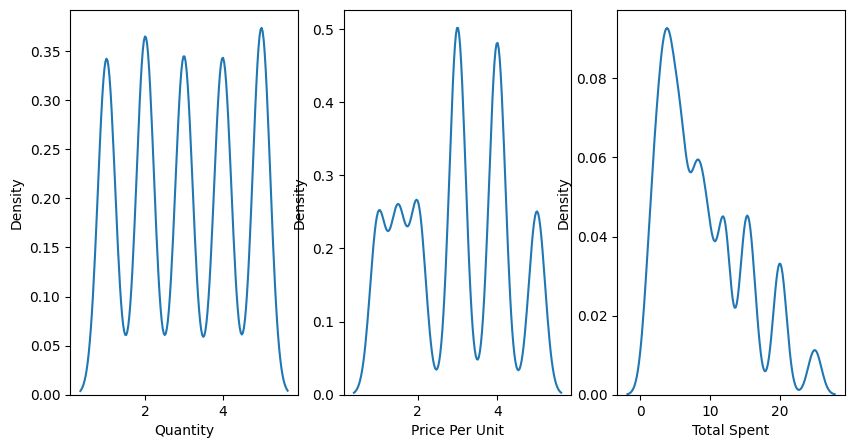

In [14]:
fg , axes = plt.subplots(1,3,figsize=(10,5))

for idx,col in enumerate(numerical_columns):
    sns.kdeplot(
                data = df[col],
                ax = axes[idx]
    )
plt.show()

In [16]:
df["Quantity"].value_counts()

Quantity
5.0    2096
2.0    2048
3.0    1936
4.0    1926
1.0    1920
Name: count, dtype: int64

**Quantity** Can we consider as Categorical Column

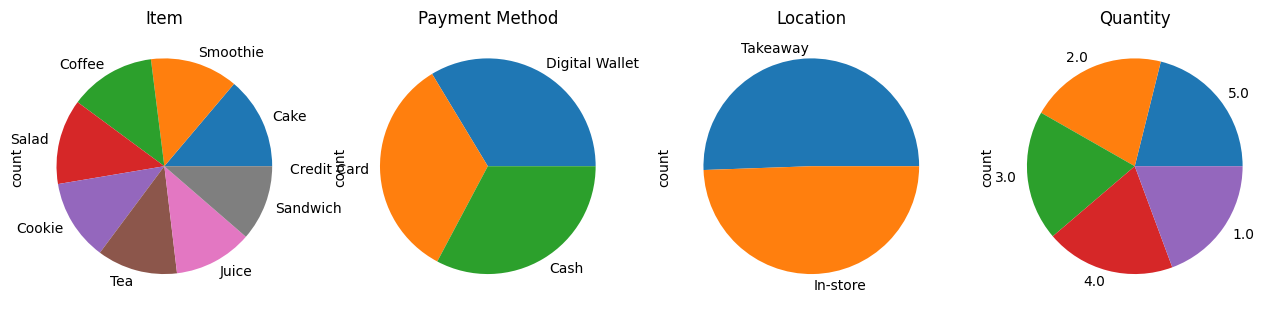

In [22]:
categorical_columns = ["Item","Payment Method","Location","Quantity"]

fg,axes = plt.subplots(1,4,figsize=(16,8))

for idx,col in enumerate(categorical_columns):
    df[col].value_counts().plot(
                            kind = "pie",
                            ax = axes[idx]
    )
    axes[idx].set_title(col)
plt.show()

#### 3.2 Box plots

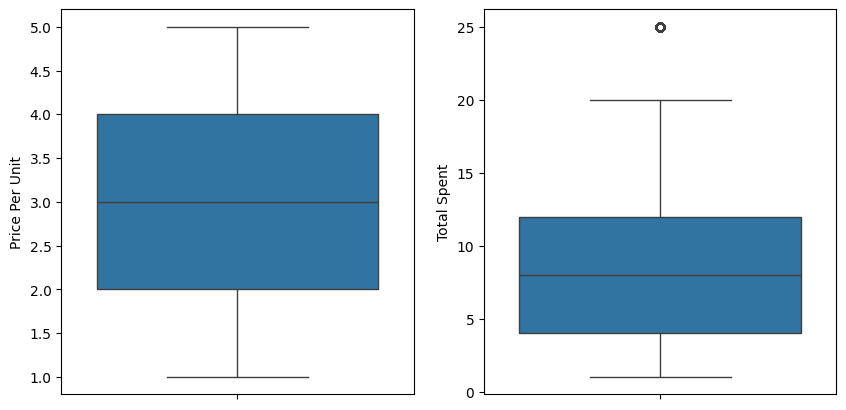

In [25]:
numerical_columns = ["Price Per Unit","Total Spent"]
fg,axes = plt.subplots(1,2,figsize=(10,5))
axes = axes.flatten()
for idx,col in enumerate(numerical_columns):
    sns.boxplot(data=df[col],ax=axes[idx])

plt.show()

### 3.3 empirical rule / 3 - sigma rule 

In [28]:
# def find_anomaly()
def find_anomaly(data):
    mean = data.mean()
    std = data.std()

    upper_bound = mean + (3*std)
    lower_bound = mean - (3*std)

    return (data >upper_bound) | (data <lower_bound)


In [34]:
for col in numerical_columns:
   n_outliers = find_anomaly(df[col]).sum()
   n_outlier_percentage = round(n_outliers/len(df),2)
   print(f"{col} ---> outliers : {n_outliers} ({n_outlier_percentage})")

Price Per Unit ---> outliers : 0 (0.0)
Total Spent ---> outliers : 0 (0.0)


### 3.4 IQR Method

In [ ]:
# def find_anomaly()
def find_anomaly(data):
    Q1 = np.percentile(data,25)
    Q3 = np.percentile(data,75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR

    return (data >upper_bound) | (data <lower_bound)


In [35]:
for col in numerical_columns:
   n_outliers = find_anomaly(df[col]).sum()
   n_outlier_percentage = round(n_outliers/len(df),2)
   print(f"{col} ---> outliers : {n_outliers} ({n_outlier_percentage})")

Price Per Unit ---> outliers : 0 (0.0)
Total Spent ---> outliers : 0 (0.0)


In [36]:
df.to_csv("data/processed/Cafe_sales_handled_outliers.csv",index=False)